# Notebook 1 – PCA: Ein Überblick
**Maschinelles Lernen mit Python · Kapitel 12: Dimensionsreduktion**  

---

## Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- intuitiv erklären, was Hauptkomponenten geometrisch bedeuten
- `pca.components_` und `pca.explained_variance_` visuell interpretieren
- den Unterschied zwischen **Dimensionsreduktion** und **Informationsverlust** beschreiben
- einschätzen, was verloren geht, wenn von 2D auf 1D reduziert wird

---

## Kontext

Dieses Notebook erklärt die **geometrische Intuition hinter PCA** anhand eines synthetischen 2D-Datensatzes. Wir visualisieren die Hauptkomponenten als Vektoren und sehen, was nach der Projektion auf 1D verloren geht.

> **Verbindung zu den Folien:** Hauptkomponenten als Vektoren, visuelle Progression (Datenpunkte → Vektoren → Projektion)

---
## Teil 1: Der Datensatz – 200 korrelierte Punkte

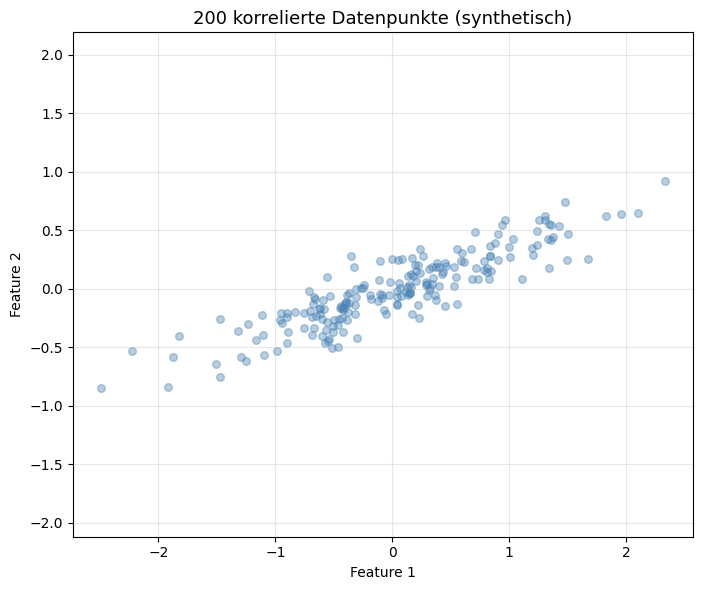

Datensatz: 200 Punkte, 2 Dimensionen
Korrelation Feature1 und Feature2: 0.8894

Beobachtung: In welcher Richtung zeigen die Daten die groesste Streuung?
Diese Richtung wird PCA als Hauptkomponente 1 finden.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Erzeuge korrelierte 2D-Daten (reproduzierbar durch seed=1)
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, color='steelblue', s=30)
plt.axis('equal')
plt.title('200 korrelierte Datenpunkte (synthetisch)', fontsize=13)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Datensatz: {X.shape[0]} Punkte, {X.shape[1]} Dimensionen')
print(f'Korrelation Feature1 und Feature2: {np.corrcoef(X[:,0], X[:,1])[0,1]:.4f}')
print()
print('Beobachtung: In welcher Richtung zeigen die Daten die groesste Streuung?')
print('Diese Richtung wird PCA als Hauptkomponente 1 finden.')

---
## Teil 2: PCA berechnen – Hauptkomponenten finden

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # Alle Komponenten berechnen
pca.fit(X)

print('=' * 55)
print('Ergebnis der PCA (n_components=2):')
print('=' * 55)
print()
print('pca.components_ (die Hauptkomponentenvektoren):')
for i, comp in enumerate(pca.components_):
    print(f'  PC{i+1}: [{comp[0]:+.4f}, {comp[1]:+.4f}]')
print()
print('pca.explained_variance_ (Eigenwerte):')
for i, ev in enumerate(pca.explained_variance_):
    print(f'  PC{i+1}: {ev:.6f}')
print()
print('pca.explained_variance_ratio_ (Anteil an Gesamtvarianz):')
for i, evr in enumerate(pca.explained_variance_ratio_):
    bar = chr(9608) * int(evr * 40)
    print(f'  PC{i+1}: {evr*100:5.2f}%  {bar}')
print(f'\n  Summe: {sum(pca.explained_variance_ratio_)*100:.2f}%')

Ergebnis der PCA (n_components=2):

pca.components_ (die Hauptkomponentenvektoren):
  PC1: [+0.9445, +0.3286]
  PC2: [-0.3286, +0.9445]

pca.explained_variance_ (Eigenwerte):
  PC1: 0.762532
  PC2: 0.018478

pca.explained_variance_ratio_ (Anteil an Gesamtvarianz):
  PC1: 97.63%  ███████████████████████████████████████
  PC2:  2.37%  

  Summe: 100.00%


---
## Teil 3: Visualisierung der Hauptkomponentenvektoren

**Wie lese ich diese Darstellung?**
- Jeder **Pfeil** zeigt die Richtung einer Hauptkomponente
- Die **Länge** ist proportional zur erklärten Varianz (= Eigenwert)
- PC1 ist länger als PC2 → PC1 ist wichtiger

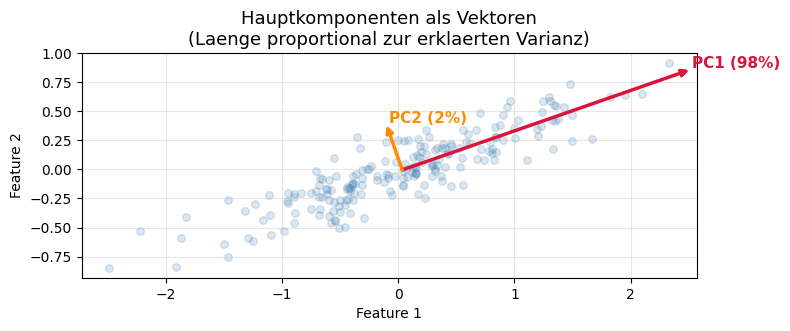

Interpretation:
  PC1 (rot):    Richtung der GROESSTEN Streuung  -> 97.6% Varianz
  PC2 (orange): steht SENKRECHT auf PC1          -> 2.4% Varianz
  -> PC1 ist laenger, weil diese Richtung mehr Information traegt


In [3]:
def draw_vector(v0, v1, ax=None, color='red', label=''):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->', linewidth=2.5,
                      color=color, shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)
    if label:
        ax.text(v1[0]+0.02, v1[1]+0.02, label, color=color,
                fontsize=11, fontweight='bold')

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X[:, 0], X[:, 1], alpha=0.2, color='steelblue', s=30)

colors_vec = ['crimson', 'darkorange']
for i, (length, vector) in enumerate(zip(pca.explained_variance_, pca.components_)):
    v = vector * 3 * np.sqrt(length)  # Laenge proportional zur Varianz
    draw_vector(pca.mean_, pca.mean_ + v, ax=ax,
                color=colors_vec[i],
                label=f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.0f}%)')

ax.set_aspect('equal')
ax.set_title('Hauptkomponenten als Vektoren\n(Laenge proportional zur erklaerten Varianz)', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Interpretation:')
print(f'  PC1 (rot):    Richtung der GROESSTEN Streuung  -> {pca.explained_variance_ratio_[0]*100:.1f}% Varianz')
print(f'  PC2 (orange): steht SENKRECHT auf PC1          -> {pca.explained_variance_ratio_[1]*100:.1f}% Varianz')
print('  -> PC1 ist laenger, weil diese Richtung mehr Information traegt')

---
## Teil 4: Dimensionsreduktion – von 2D auf 1D

Wir behalten nur **PC1** und verwerfen PC2. Was bleibt? Was geht verloren?

Original:            (200, 2)
Nach PCA (1D):       (200, 1)
Projektion auf 2D:   (200, 2)  <- Punkte liegen jetzt auf PC1-Gerade

Informationserhalt:  97.63%
Informationsverlust: 2.37%


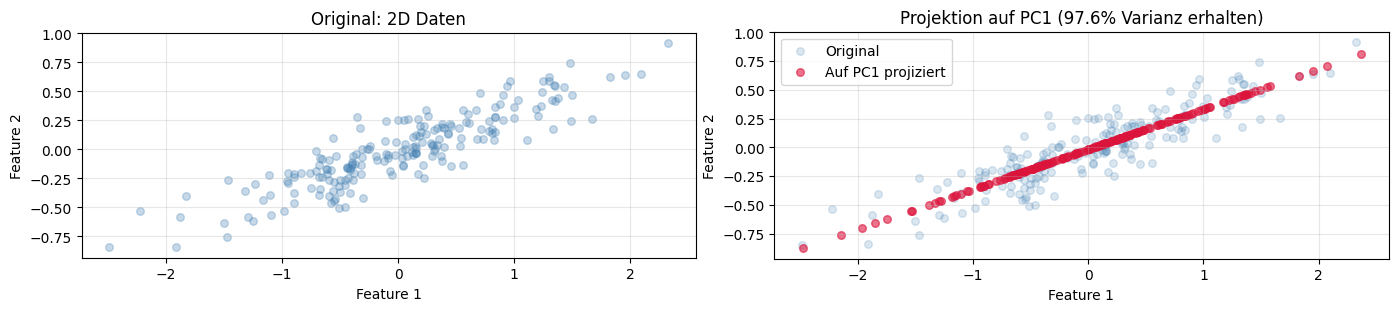

Beobachtung: Die roten Punkte liegen alle auf einer Linie (der PC1-Achse).
Das ist die Information entlang PC2, die verloren gegangen ist.


In [4]:
pca_1d = PCA(n_components=1)
pca_1d.fit(X)
X_pca = pca_1d.transform(X)            # 2D -> 1D
X_new = pca_1d.inverse_transform(X_pca)  # 1D -> zurueck nach 2D (Projektion)

print(f'Original:            {X.shape}')
print(f'Nach PCA (1D):       {X_pca.shape}')
print(f'Projektion auf 2D:   {X_new.shape}  <- Punkte liegen jetzt auf PC1-Gerade')
print(f'\nInformationserhalt:  {pca_1d.explained_variance_ratio_[0]*100:.2f}%')
print(f'Informationsverlust: {(1-pca_1d.explained_variance_ratio_[0])*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.3, color='steelblue', s=30)
axes[0].set_title('Original: 2D Daten', fontsize=12)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X[:, 0], X[:, 1], alpha=0.2, color='steelblue', s=30, label='Original')
axes[1].scatter(X_new[:, 0], X_new[:, 1], alpha=0.6, color='crimson', s=30, label='Auf PC1 projiziert')
axes[1].set_title(
    f'Projektion auf PC1 ({pca_1d.explained_variance_ratio_[0]*100:.1f}% Varianz erhalten)',
    fontsize=12)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Beobachtung: Die roten Punkte liegen alle auf einer Linie (der PC1-Achse).')
print('Das ist die Information entlang PC2, die verloren gegangen ist.')

---
## Teil 5: Kumulierter Varianzplot – wie viele Komponenten brauche ich?

Dieser Plot ist eines der wichtigsten Diagnosewerkzeuge nach einer PCA. Er zeigt, wie viel Varianz mit zunehmender Anzahl an Komponenten erklärt wird.

**Faustregeln:**
- >= 80 % Varianz: ausreichend für viele Vorverarbeitungszwecke
- >= 95 % Varianz: empfohlen für Visualisierung
- >= 99 % Varianz: für verlustfreie Komprimierung

**Tipp:** `PCA(n_components=0.95)` wählt automatisch so viele Komponenten wie nötig!

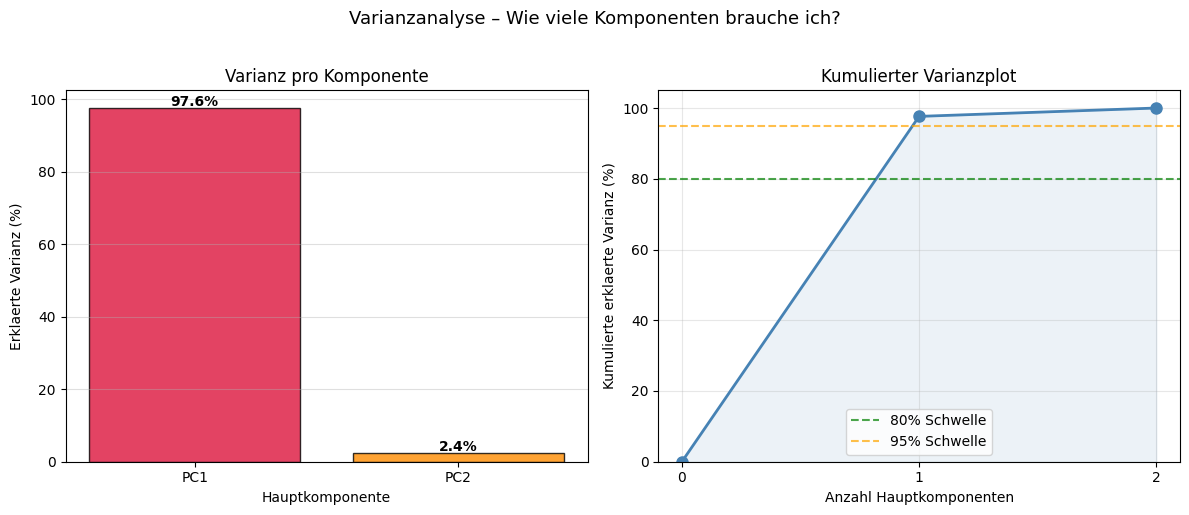

In [5]:
pca_full = PCA(n_components=2)
pca_full.fit(X)

kumuliert = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Barplot: erklaerte Varianz pro Komponente
ax1.bar([1, 2], pca_full.explained_variance_ratio_ * 100,
        color=['crimson', 'darkorange'], edgecolor='black', alpha=0.8)
ax1.set_xlabel('Hauptkomponente')
ax1.set_ylabel('Erklaerte Varianz (%)')
ax1.set_title('Varianz pro Komponente')
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['PC1', 'PC2'])
for i, v in enumerate(pca_full.explained_variance_ratio_ * 100):
    ax1.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
ax1.grid(True, axis='y', alpha=0.4)

# Kumulierter Varianzplot
ax2.plot([0, 1, 2], [0] + list(kumuliert * 100), 'o-',
         color='steelblue', linewidth=2, markersize=8)
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Schwelle')
ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% Schwelle')
ax2.fill_between([0, 1, 2], [0] + list(kumuliert * 100), alpha=0.1, color='steelblue')
ax2.set_xlabel('Anzahl Hauptkomponenten')
ax2.set_ylabel('Kumulierte erklaerte Varianz (%)')
ax2.set_title('Kumulierter Varianzplot')
ax2.set_ylim(0, 105)
ax2.set_xticks([0, 1, 2])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Varianzanalyse – Wie viele Komponenten brauche ich?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Lernauftrag

**Aufgabe 1 – Vektorlänge interpretieren:**  
In der Visualisierung (Teil 3) ist PC1 länger als PC2. Was bedeutet die Länge des Vektors – und was bedeutet seine Richtung? Erklären Sie in eigenen Worten.

**Aufgabe 2 – Informationsverlust quantifizieren:**  
Welche Information geht bei der Projektion von 2D auf 1D verloren? Beschreiben Sie anhand der Visualisierung in Teil 4, was mit den blauen Punkten passiert.

**Aufgabe 3 – Eigener Datensatz mit geringerer Korrelation:**  
Erzeugen Sie einen neuen Datensatz mit schwächerer Korrelation (Hinweis: Verwenden Sie eine nahezu diagonale Transformationsmatrix statt `rng.rand(2,2)`). Wie verändert sich die `explained_variance_ratio_`?

In [6]:
# Aufgabe 1 & 2: Hier Ihre schriftliche Antwort als Kommentar eintragen
# Aufgabe 1: ...
# Aufgabe 2: ...


In [7]:
# Aufgabe 3: Datensatz mit geringerer Korrelation
rng2 = np.random.RandomState(42)

# Tipp: Eine fast-diagonale Matrix erzeugt schwach korrelierte Daten
# transform_matrix = np.array([[1.0, 0.1], [0.1, 1.0]])
# X2 = np.dot(transform_matrix, rng2.randn(2, 200)).T

# Ihr Code hier:
